# Diffusion Models

A diffusion model learns to denoise. Train it to remove a tiny bit of noise from a noisy image, repeat that backwards a thousand times, and you have an image generator.


## Problem Definition

GANs generate one-shot: noise in, image out, one forward pass. They are fast and hard to train. 

Diffusion models generate iteratively: start from pure noise, denoise in small steps, image emerges. **They are slow and easy to train.**


Beyond training stability, diffusion's iterative structure is what unlocks everything modern image generation does: text conditioning, inpainting, image editing, super-resolution, controllable style. Each step of the sampling loop is a place to inject a new constraint.


## Basic Concept

### Forward process

Take an image `x_0`. Add a tiny amount of Gaussian noise to get `x_1`. Add a tiny amount more to get `x_2`. Keep going for T steps until `x_T` is nearly indistinguishable from pure Gaussian noise.

```
q(x_t | x_{t-1}) = N(x_t; sqrt(1 - beta_t) * x_{t-1},  beta_t * I)
```

beta_t is a small variance schedule, typically linear from 0.0001 to 0.02 over T=1000 steps. Each step slightly shrinks the signal and injects fresh noise.


### The closed-form jump

Adding noise one step at a time is a Markov chain, but the math folds: you can sample `x_t` directly from `x_0` in one step.

```
Define alpha_t = 1 - beta_t
Define alpha_bar_t = prod_{s=1..t} alpha_s

Then:
  q(x_t | x_0) = N(x_t; sqrt(alpha_bar_t) * x_0,  (1 - alpha_bar_t) * I)

Equivalently:
  x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon
  where epsilon ~ N(0, I)
```

### The reverse process

The forward process is fixed. **The reverse process `p(x_{t-1} | x_t)` is what the neural network learns.** Diffusion models do not predict `x_{t-1}` directly; they **predict the noise `epsilon` added at step t, and the math derives `x_{t-1}` from it.**

```mermaid
flowchart TD
    X0["x_0<br/>(clean image)"] --> Q1["q(x_t|x_0)<br/>add noise"]
    Q1 --> XT["x_t<br/>(noisy)"]
    XT --> MODEL["model(x_t, t)"]
    MODEL --> EPS["predicted epsilon"]
    EPS --> LOSS["MSE against<br/>true epsilon"]

    XT -.->|sampling| STEP["p(x_{t-1}|x_t)"]
    STEP -.-> XT1["x_{t-1}"]
    XT1 -.->|repeat 1000x| X0S["x_0 (sampled)"]

    style X0 fill:#dcfce7,stroke:#16a34a
    style MODEL fill:#fef3c7,stroke:#d97706
    style LOSS fill:#fecaca,stroke:#dc2626
    style X0S fill:#dbeafe,stroke:#2563eb
```

### The training loss

For every training step:

1. Sample a real image `x_0`.
2. Sample a timestep `t` uniformly from [1, T].
3. Sample noise `epsilon ~ N(0, I)`.
4. Compute `x_t = sqrt(alpha_bar_t) * x_0 + sqrt(1 - alpha_bar_t) * epsilon`.
5. Predict `epsilon_theta(x_t, t)` with the network.
6. Minimise `|| epsilon - epsilon_theta(x_t, t) ||^2`.

That is it. The neural network learns to predict the noise at any timestep. The loss is MSE. There is no adversarial game, no collapse, no oscillation.


### The Sampler

To generate: start from `x_T ~ N(0, I)` and walk backwards one step at a time.

```
for t = T, T-1, ..., 1:
    eps = model(x_t, t)
    x_{t-1} = (1 / sqrt(alpha_t)) * (x_t - (beta_t / sqrt(1 - alpha_bar_t)) * eps) + sqrt(beta_t) * z
    where z ~ N(0, I) if t > 1, else 0
return x_0
```

The key is that even though the reverse conditional is not known in closed form in general, for this specific Gaussian forward process it is. The ugly-looking coefficients are what Bayes' rule gives you.

### Why 1000 steps

The forward noise schedule is chosen so each step adds just enough noise that the reverse step is nearly Gaussian. Too few steps and the reverse step is far from Gaussian, the network cannot model it well. Too many steps and sampling becomes expensive with diminishing gain. T=1000 with a linear schedule is the DDPM default.

### DDIM: 20x faster sampling

Training is the same. Sampling changes. DDIM (Song et al., 2020) defines a deterministic reverse process that skips timesteps without retraining. Sampling in 50 steps with DDIM gives near-1000-step DDPM quality. Every production system uses DDIM or an even faster variant (DPM-Solver, Euler ancestral).

### Time conditioning

The network `epsilon_theta(x_t, t)` needs to know which timestep it is denoising. Modern diffusion models inject `t` via sinusoidal time embeddings (same idea as positional encoding in transformers) that get added to feature maps at every U-Net level.

```
t_embedding = sinusoidal(t)
feature_map += MLP(t_embedding)
```

Without time conditioning the network has to guess the noise level from the image itself, which works but is much less sample-efficient.


# Build your Own

## Noise Schedule

In [39]:
import torch

def linear_beta_schedule(T=1000, beta_start=1e-4, beta_end=2e-2):
    return torch.linspace(beta_start, beta_end, T)

def precompute_schedule(betas):
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    return {
        "betas": betas,
        "alphas": alphas,
        "alphas_cumprod": alphas_cumprod,
        "sqrt_alphas_cumprod": torch.sqrt(alphas_cumprod),
        "sqrt_one_minus_alphas_cumprod": torch.sqrt(1.0 - alphas_cumprod),
        "sqrt_recip_alphas": torch.sqrt(1.0 / alphas)
    }

## Forward diffusion

In [40]:
def q_sample(x0, t, noise, schedule):
    sqrt_a = schedule["sqrt_alphas_cumprod"][t].view(-1, 1, 1, 1)
    sqrt_one_minus_a = schedule["sqrt_one_minus_alphas_cumprod"][t].view(-1, 1, 1, 1)
    return sqrt_a * x0 + sqrt_one_minus_a * noise


## A tiny time-conditioned U-Net

In [41]:
import torch.nn as nn
import torch.nn.functional as F
import math

def timestep_embedding(t, dim=64):
    half = dim // 2
    freqs = torch.exp(
        -math.log(10000) * torch.arange(half, device=t.device) / half
    )
    args = t[:, None].float() * freqs[None]
    emb = torch.cat([args.sin(), args.cos()], dim=-1)
    return emb

class TinyUNet(nn.Module):
    """Minimal time-conditioned U-Net that predicts noise epsilon given (x_t, t)."""

    def __init__(self, img_channels=3, base=32, t_dim=64):
        super().__init__()
        self.t_dim = t_dim

        # Map sinusoidal t-embedding -> richer time features
        self.t_mlp = nn.Sequential(
            nn.Linear(t_dim, base * 4),
            nn.SiLU(),
            nn.Linear(base * 4, base * 4),
        )
        # Project time features to match encoder channel count (base*2)
        # so we can add them onto the downsampled feature map
        self.time_proj = nn.Linear(base * 4, base * 2)

        # Encoder: keep H,W then downsample 2x
        self.enc1 = nn.Conv2d(img_channels, base, 3, padding=1)       # (B,C,H,W) -> (B,base,H,W)
        self.enc2 = nn.Conv2d(base, base * 2, 4, stride=2, padding=1) # -> (B,base*2,H/2,W/2)
        self.mid = nn.Conv2d(base * 2, base * 2, 3, padding=1)        # bottleneck

        # Decoder: upsample 2x, then fuse skip from enc1
        self.dec1 = nn.ConvTranspose2d(base * 2, base, 4, stride=2, padding=1)  # -> (B,base,H,W)
        # after concat [upsampled, enc1] channels = base + base = base*2
        self.dec2 = nn.Conv2d(base * 2, img_channels, 3, padding=1)             # -> predicted noise

    def forward(self, x, t):
        # x: noisy image (B, C, H, W); t: timesteps (B,)
        t_emb = timestep_embedding(t, self.t_dim)   # (B, t_dim)
        t_emb = self.t_mlp(t_emb)                   # (B, base*4)
        # (B, base*2, 1, 1) — broadcasts over H,W when added to features
        t_proj = self.time_proj(t_emb)[:, :, None, None]

        h1 = F.silu(self.enc1(x))                   # skip features (fine spatial detail)
        h2 = F.silu(self.enc2(h1)) + t_proj         # inject time at coarse scale
        h3 = F.silu(self.mid(h2)) + t_proj          # time again in bottleneck

        d1 = F.silu(self.dec1(h3))                  # back to original resolution
        d2 = torch.cat([d1, h1], dim=1)             # U-Net skip connection
        return self.dec2(d2)                        # epsilon_hat, same shape as x

# Training Loop

In [42]:
def train_step(model, x0, schedule, optimizer, device, T=1000):
    model.train()
    x0 = x0.to(device)
    bs = x0.size(0)

    t = torch.randint(0, T, (bs,), device=device)
    noise = torch.randn_like(x0)

    x_t = q_sample(x0, t, noise, schedule)
    pred = model(x_t, t)
    loss = F.mse_loss(pred, noise)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    return loss.item()

## Sampler


In [43]:
@torch.no_grad()
def sample_ddpm(model, schedule, shape, T=1000, device="cpu", x_init=None):
    """Ancestral DDPM: T network calls, stochastic (adds noise each step)."""
    model.eval()
    x = torch.randn(shape, device=device) if x_init is None else x_init.clone()
    betas = schedule["betas"].to(device)
    # must use cumprod term: sqrt(1 - alpha_bar_t), not a missing key
    sqrt_one_minus_abar = schedule["sqrt_one_minus_alphas_cumprod"].to(device)
    sqrt_recip_alphas = schedule["sqrt_recip_alphas"].to(device)

    for t in reversed(range(T)):
        t_batch = torch.full((shape[0],), t, dtype=torch.long, device=device)
        eps = model(x, t_batch)
        coef = betas[t] / sqrt_one_minus_abar[t]
        mean = sqrt_recip_alphas[t] * (x - coef * eps)
        if t > 0:
            x = mean + torch.sqrt(betas[t]) * torch.randn_like(x)
        else:
            x = mean
    return x


@torch.no_grad()
def sample_ddim(model, schedule, shape, steps=50, T=1000, device="cpu", eta=0.0, x_init=None):
    """DDIM: subsample timesteps (often 20–50). eta=0 → deterministic."""
    model.eval()
    x = torch.randn(shape, device=device) if x_init is None else x_init.clone()
    alphas_cumprod = schedule["alphas_cumprod"].to(device)

    # evenly spaced indices from T-1 down to 0
    ts = torch.linspace(T - 1, 0, steps + 1).long().tolist()
    for i in range(steps):
        t, t_prev = ts[i], ts[i + 1]
        t_batch = torch.full((shape[0],), t, dtype=torch.long, device=device)
        eps = model(x, t_batch)

        a_t = alphas_cumprod[t]
        a_prev = alphas_cumprod[t_prev] if t_prev >= 0 else alphas_cumprod.new_tensor(1.0)
        # predict x0 from epsilon parameterization
        x0_pred = (x - torch.sqrt(1.0 - a_t) * eps) / torch.sqrt(a_t)
        x0_pred = x0_pred.clamp(-1, 1)

        sigma = (
            eta
            * torch.sqrt(((1.0 - a_prev) / (1.0 - a_t)).clamp_min(0))
            * torch.sqrt((1.0 - a_t / a_prev).clamp_min(0))
        )
        dir_xt = torch.sqrt((1.0 - a_prev - sigma ** 2).clamp_min(0)) * eps
        noise = torch.randn_like(x) * sigma if (eta > 0 and t_prev > 0) else 0.0
        x = torch.sqrt(a_prev) * x0_pred + dir_xt + noise
    return x

device=mps  T=300  alpha_bar[0]=0.9999  alpha_bar[-1]=0.048058
params: 138,275


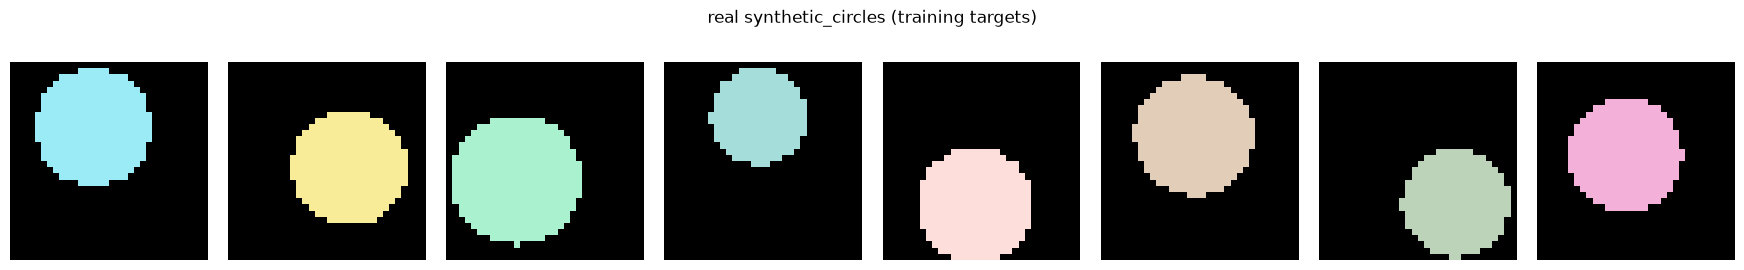

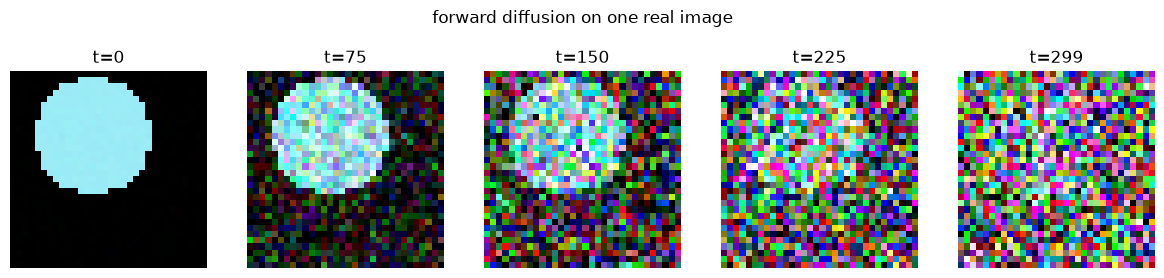

epoch 1/50  mse 0.9463


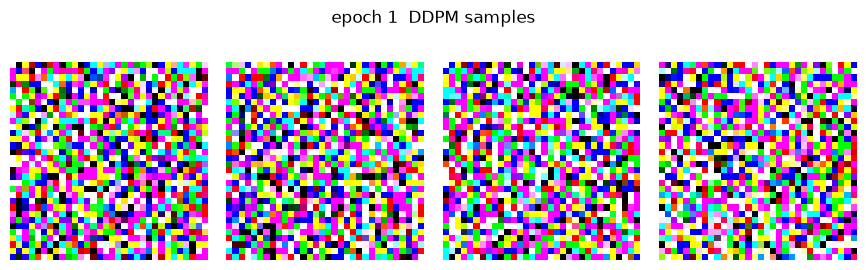

epoch 2/50  mse 0.8147
epoch 3/50  mse 0.6054
epoch 4/50  mse 0.4542
epoch 5/50  mse 0.3658


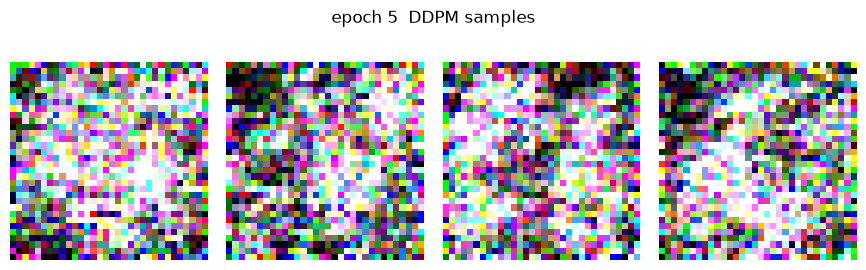

epoch 6/50  mse 0.3126
epoch 7/50  mse 0.2876
epoch 8/50  mse 0.2753
epoch 9/50  mse 0.2650
epoch 10/50  mse 0.2550


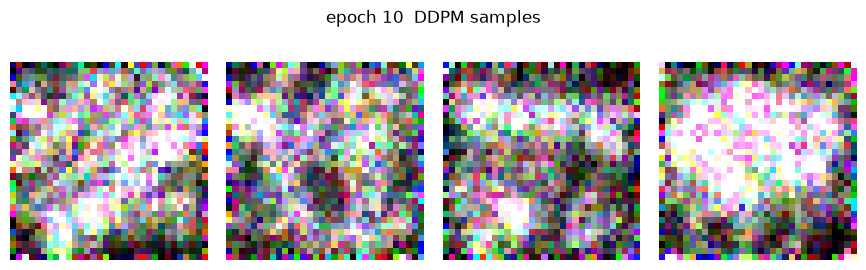

epoch 11/50  mse 0.2590
epoch 12/50  mse 0.2388
epoch 13/50  mse 0.2413
epoch 14/50  mse 0.2457
epoch 15/50  mse 0.2378


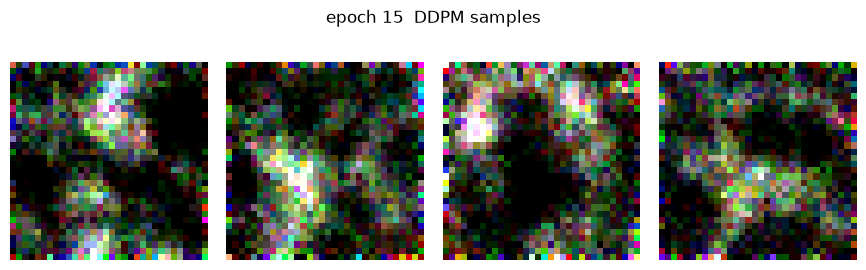

epoch 16/50  mse 0.2351
epoch 17/50  mse 0.2323
epoch 18/50  mse 0.2238
epoch 19/50  mse 0.2230
epoch 20/50  mse 0.2179


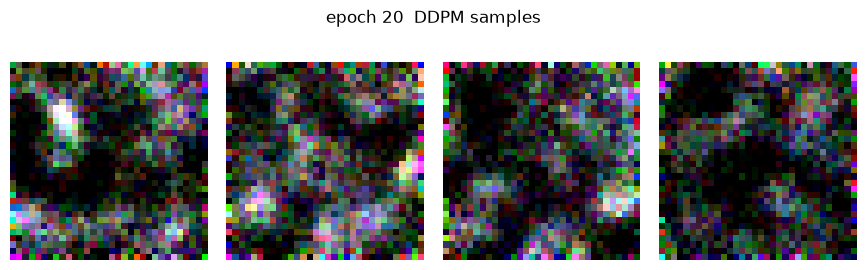

epoch 21/50  mse 0.2183
epoch 22/50  mse 0.2162
epoch 23/50  mse 0.2135
epoch 24/50  mse 0.2073
epoch 25/50  mse 0.2132


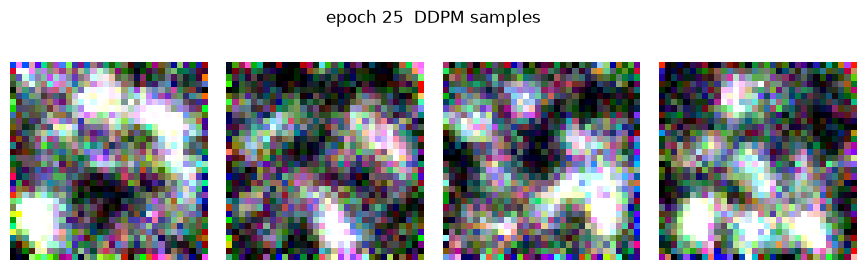

epoch 26/50  mse 0.2072
epoch 27/50  mse 0.2110
epoch 28/50  mse 0.2107
epoch 29/50  mse 0.2038
epoch 30/50  mse 0.2009


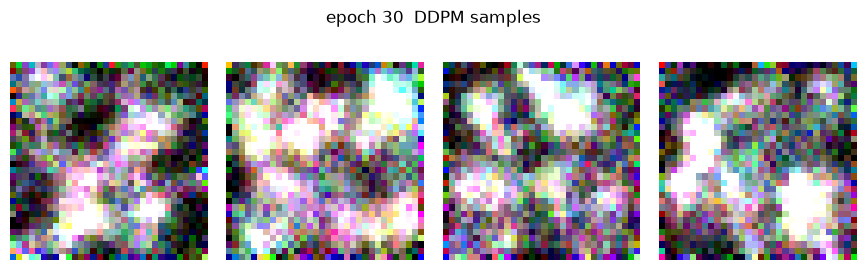

epoch 31/50  mse 0.2019
epoch 32/50  mse 0.1960
epoch 33/50  mse 0.1968
epoch 34/50  mse 0.1946
epoch 35/50  mse 0.1960


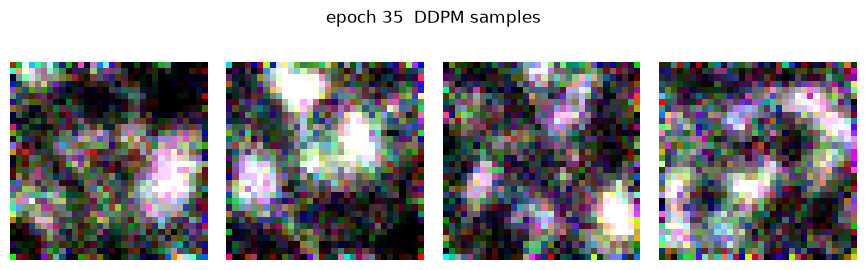

epoch 36/50  mse 0.1945
epoch 37/50  mse 0.1939
epoch 38/50  mse 0.1989
epoch 39/50  mse 0.1902
epoch 40/50  mse 0.1790


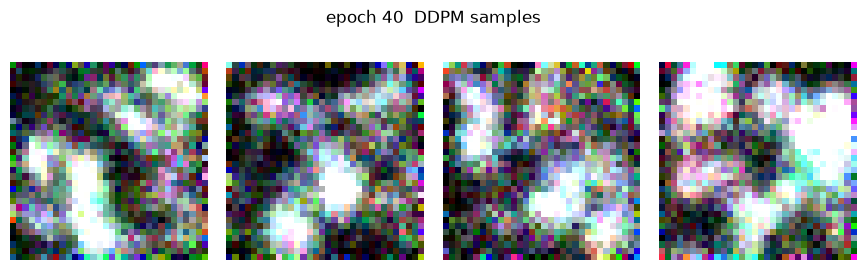

epoch 41/50  mse 0.1905
epoch 42/50  mse 0.1787
epoch 43/50  mse 0.1724
epoch 44/50  mse 0.1688
epoch 45/50  mse 0.1699


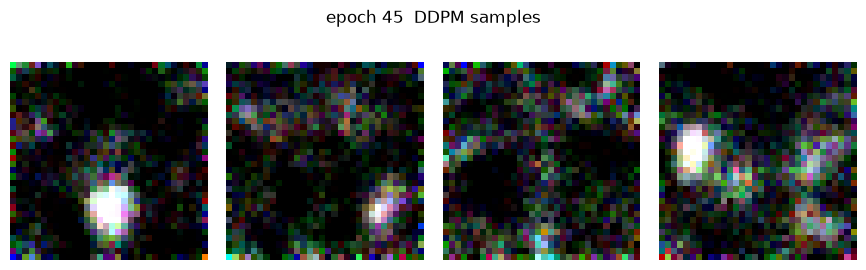

epoch 46/50  mse 0.1771
epoch 47/50  mse 0.1700
epoch 48/50  mse 0.1742
epoch 49/50  mse 0.1708
epoch 50/50  mse 0.1620


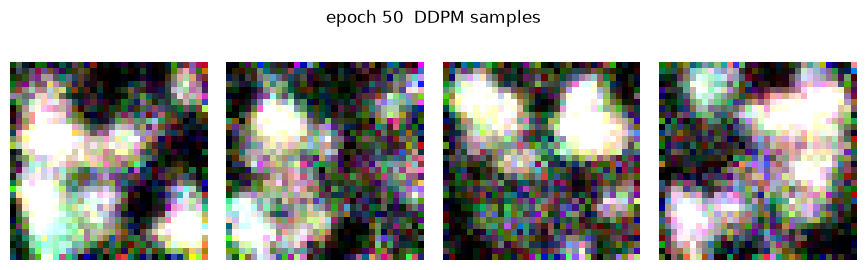

DDPM: 300 steps, 0.16s, range [-2.22, 6.88]
DDIM: 20 steps, 0.02s, range [-1.02, 1.02]
speedup ≈ 7.2x


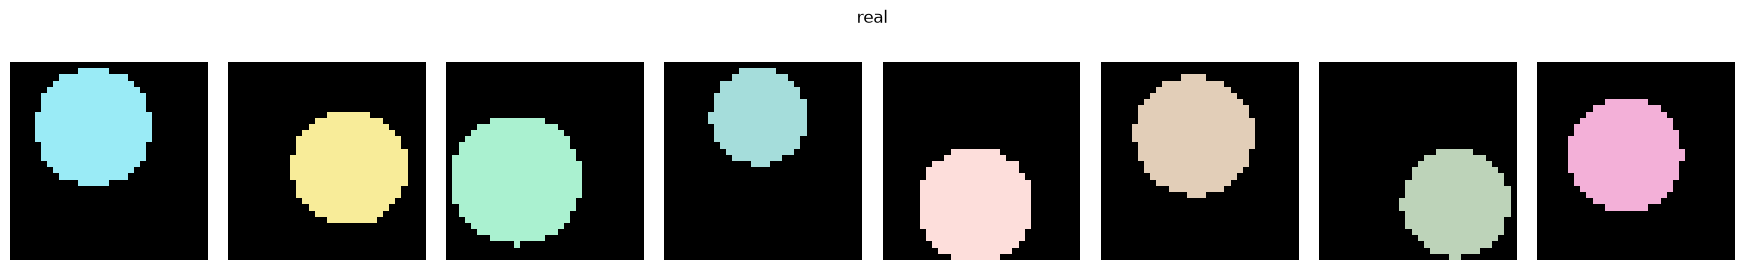

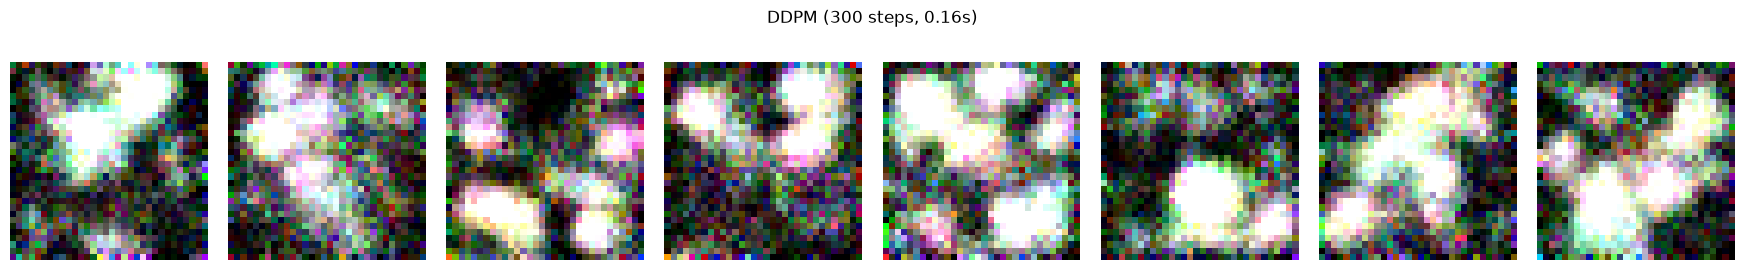

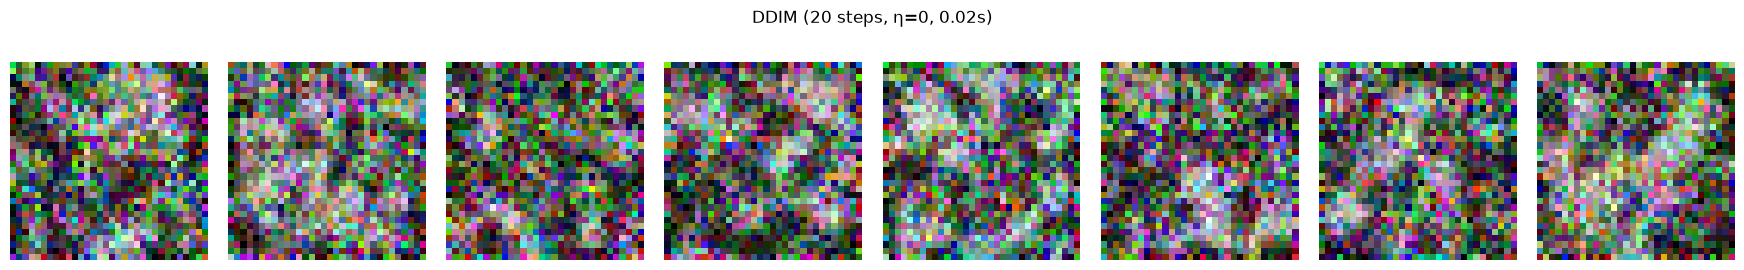

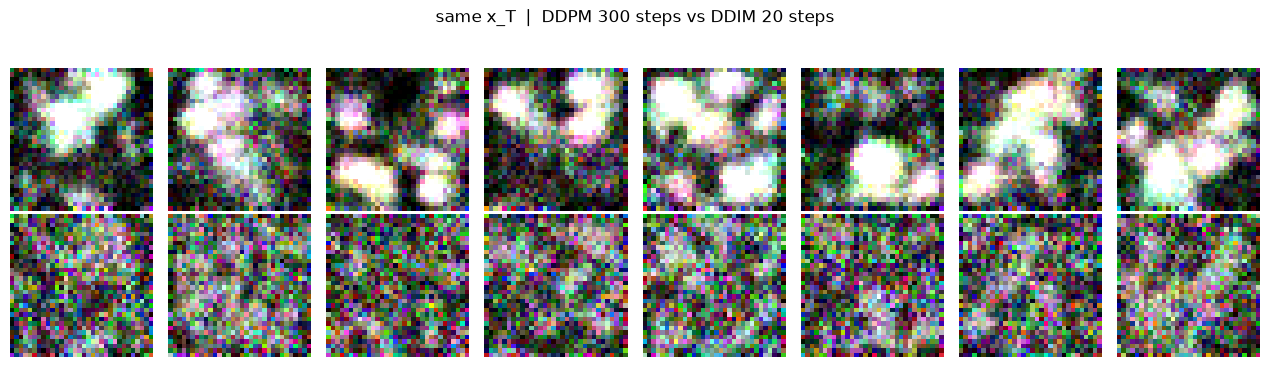

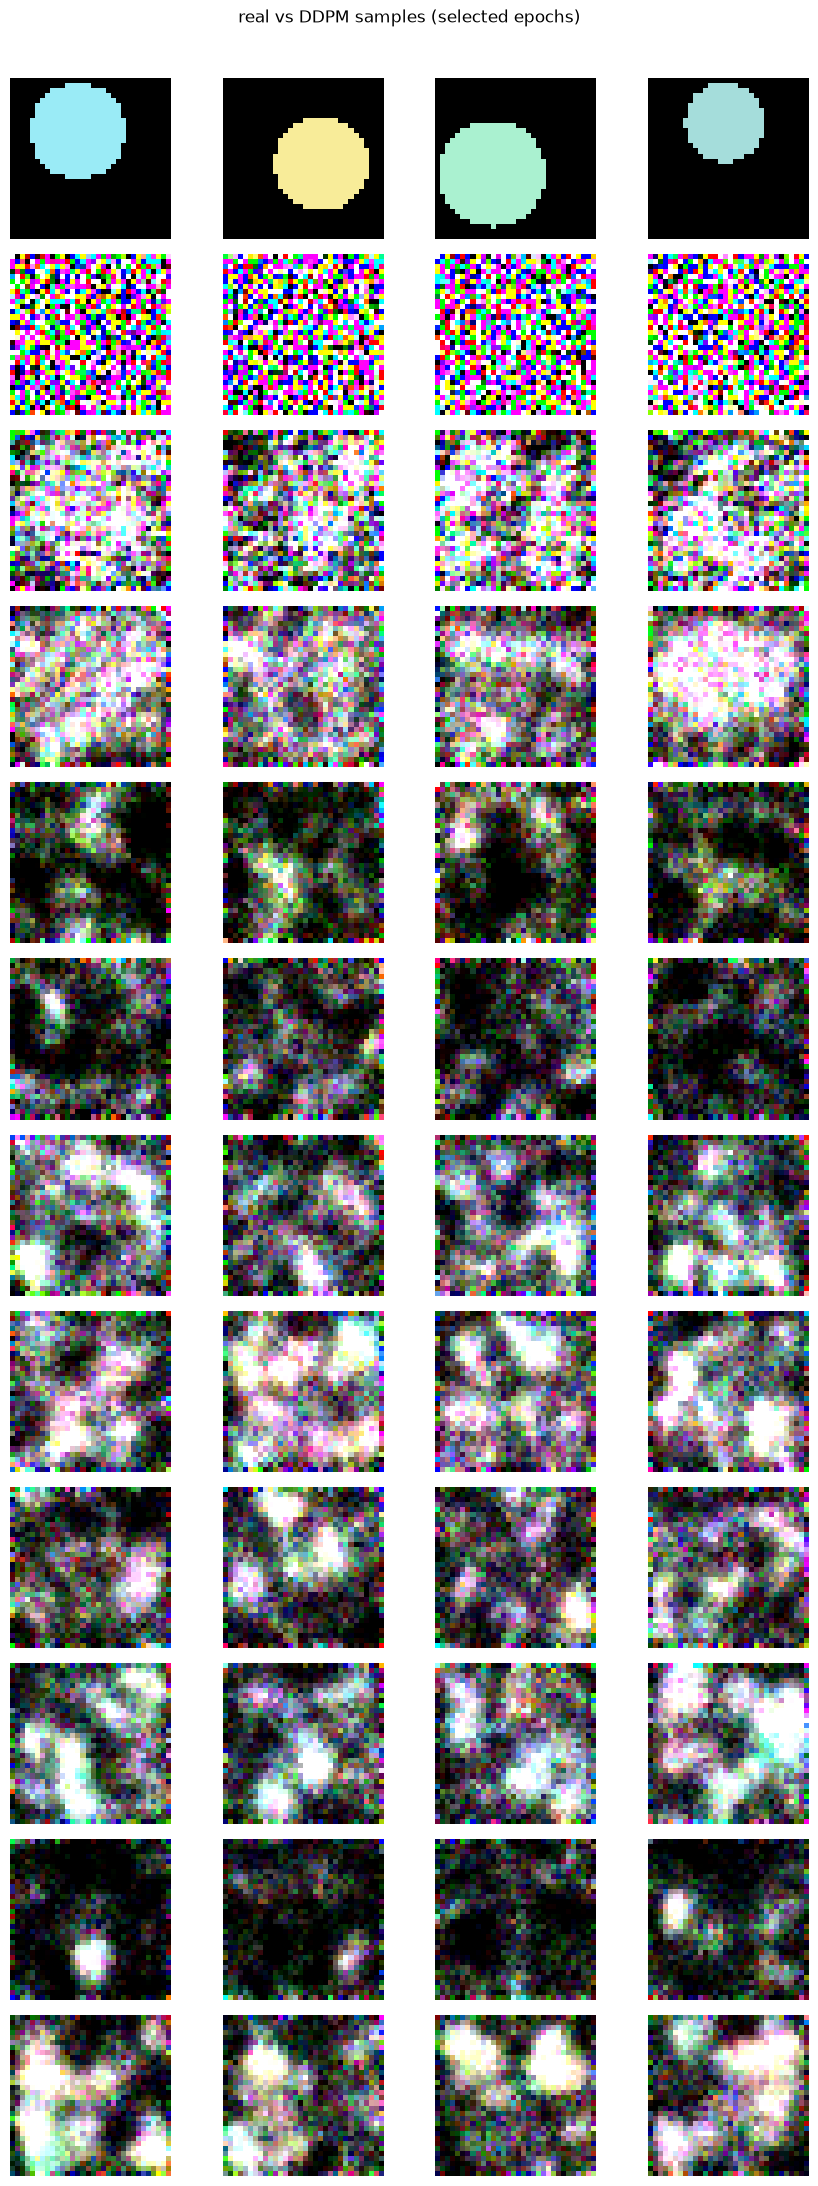

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

IMG_SIZE = 32


def synthetic_circles(num=2000, size=IMG_SIZE, seed=0):
    """Black background + one saturated circle — easy for a tiny diffusion demo."""
    rng = np.random.default_rng(seed)
    imgs = np.full((num, 3, size, size), -1.0, dtype=np.float32)
    yy, xx = np.meshgrid(np.arange(size), np.arange(size), indexing="ij")
    for i in range(num):
        r = rng.uniform(size * 0.2, size * 0.35)
        cx, cy = rng.uniform(r, size - r, size=2)
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 < r ** 2
        # saturated colors so blobs are obvious after sampling
        color = rng.uniform(0.2, 1.0, size=3).astype(np.float32)
        for c in range(3):
            imgs[i, c][mask] = color[c]
    return torch.from_numpy(imgs)


def schedule_to(schedule, device):
    return {k: v.to(device) for k, v in schedule.items()}


def to_display(imgs, up=4):
    """[-1,1] NCHW -> upsampled HWC [0,1] for clearer imshow."""
    x = imgs.detach().float().cpu().clamp(-1, 1)
    x = (x + 1) * 0.5
    if up > 1:
        x = F.interpolate(x, scale_factor=up, mode="nearest")
    return x.permute(0, 2, 3, 1).numpy()


def show_image_row(imgs_nchw, title, panel=2.2):
    imgs = to_display(imgs_nchw)
    n = imgs.shape[0]
    fig, axes = plt.subplots(1, n, figsize=(panel * n, panel + 0.4))
    if n == 1:
        axes = [axes]
    for ax, im in zip(axes, imgs):
        ax.imshow(im, interpolation="nearest")
        ax.axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()


def show_forward_diffusion(x0, schedule, T, device, timesteps=None):
    if timesteps is None:
        timesteps = [0, T // 4, T // 2, 3 * T // 4, T - 1]
    x0 = x0[:1].to(device)
    cols, labels = [], []
    for t_val in timesteps:
        t = torch.tensor([t_val], device=device)
        x_t = q_sample(x0, t, torch.randn_like(x0), schedule)
        cols.append(x_t[0].cpu())
        labels.append(f"t={t_val}")
    imgs = to_display(torch.stack(cols, 0))
    fig, axes = plt.subplots(1, len(imgs), figsize=(2.4 * len(imgs), 2.6))
    for ax, im, lab in zip(axes, imgs, labels):
        ax.imshow(im, interpolation="nearest")
        ax.set_title(lab)
        ax.axis("off")
    fig.suptitle("forward diffusion on one real image", y=1.05)
    plt.tight_layout()
    plt.show()


torch.manual_seed(0)
np.random.seed(0)
device = "mps" if torch.backends.mps.is_available() else "cpu"
T = 300  # fewer steps: faster sampling, still enough for toy circles
epochs = 50
viz_every = 5

schedule = schedule_to(
    precompute_schedule(linear_beta_schedule(T=T, beta_start=1e-4, beta_end=2e-2)),
    device,
)
print(
    f"device={device}  T={T}  "
    f"alpha_bar[0]={float(schedule['alphas_cumprod'][0]):.4f}  "
    f"alpha_bar[-1]={float(schedule['alphas_cumprod'][-1]):.6f}"
)

data = synthetic_circles(num=2000, size=IMG_SIZE)
loader = DataLoader(TensorDataset(data), batch_size=64, shuffle=True, drop_last=True)
model = TinyUNet(img_channels=3, base=32).to(device)
opt = torch.optim.Adam(model.parameters(), lr=2e-4, betas=(0.9, 0.999))
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

show_image_row(data[:8], "real synthetic_circles (training targets)")
show_forward_diffusion(data[:1], schedule, T, device)

epoch_samples = []  # (epoch_idx, imgs_hwc)
for epoch in range(epochs):
    losses = []
    for (batch,) in loader:
        losses.append(train_step(model, batch, schedule, opt, device, T=T))
    print(f"epoch {epoch + 1}/{epochs}  mse {np.mean(losses):.4f}")

    if (epoch + 1) % viz_every == 0 or epoch == 0:
        samples = sample_ddpm(
            model, schedule, shape=(4, 3, IMG_SIZE, IMG_SIZE), T=T, device=device
        )
        show_image_row(samples, f"epoch {epoch + 1}  DDPM samples")
        epoch_samples.append((epoch + 1, to_display(samples)))

# --- DDPM vs DDIM (same initial noise for a fair visual compare) ---
import time

n_cmp = 8
shape = (n_cmp, 3, IMG_SIZE, IMG_SIZE)
x_init = torch.randn(shape, device=device)
ddim_steps = 20

t0 = time.perf_counter()
s_ddpm = sample_ddpm(model, schedule, shape, T=T, device=device, x_init=x_init)
t_ddpm = time.perf_counter() - t0

t0 = time.perf_counter()
s_ddim = sample_ddim(
    model, schedule, shape, steps=ddim_steps, T=T, device=device, eta=0.0, x_init=x_init
)
t_ddim = time.perf_counter() - t0

print(
    f"DDPM: {T} steps, {t_ddpm:.2f}s, range [{float(s_ddpm.min()):.2f}, {float(s_ddpm.max()):.2f}]"
)
print(
    f"DDIM: {ddim_steps} steps, {t_ddim:.2f}s, range [{float(s_ddim.min()):.2f}, {float(s_ddim.max()):.2f}]"
)
print(f"speedup ≈ {t_ddpm / max(t_ddim, 1e-9):.1f}x")

show_image_row(data[:n_cmp], "real")
show_image_row(s_ddpm.clamp(-1, 1), f"DDPM ({T} steps, {t_ddpm:.2f}s)")
show_image_row(s_ddim.clamp(-1, 1), f"DDIM ({ddim_steps} steps, η=0, {t_ddim:.2f}s)")

# side-by-side pairs: each column = same x_init, top DDPM / bottom DDIM
fig, axes = plt.subplots(2, n_cmp, figsize=(1.6 * n_cmp, 3.6))
ddpm_imgs = to_display(s_ddpm.clamp(-1, 1))
ddim_imgs = to_display(s_ddim.clamp(-1, 1))
for c in range(n_cmp):
    axes[0, c].imshow(ddpm_imgs[c], interpolation="nearest")
    axes[0, c].axis("off")
    axes[1, c].imshow(ddim_imgs[c], interpolation="nearest")
    axes[1, c].axis("off")
axes[0, 0].set_ylabel("DDPM", rotation=0, labelpad=36, va="center")
axes[1, 0].set_ylabel("DDIM", rotation=0, labelpad=36, va="center")
fig.suptitle(f"same x_T  |  DDPM {T} steps vs DDIM {ddim_steps} steps", y=1.02)
plt.tight_layout()
plt.show()

# compact gallery: real + selected training epochs
rows = [("real", to_display(data[:4]))] + [(f"ep{e}", imgs) for e, imgs in epoch_samples]
fig, axes = plt.subplots(len(rows), 4, figsize=(9, 1.8 * len(rows)))
if len(rows) == 1:
    axes = np.array([axes])
for r, (label, imgs) in enumerate(rows):
    for c in range(4):
        axes[r, c].imshow(imgs[c], interpolation="nearest")
        axes[r, c].axis("off")
    axes[r, 0].set_ylabel(label, rotation=0, labelpad=32, va="center")
fig.suptitle("real vs DDPM samples (selected epochs)", y=1.01)
plt.tight_layout()
plt.show()

## Official Diffusers baseline (same data / same `x_T`)

`torchvision` has no DDPM. The standard PyTorch ecosystem implementation is Hugging Face **Diffusers**: `UNet2DModel` + `DDPMScheduler` / `DDIMScheduler`.

Train that UNet on the **same** `synthetic_circles` set, then sample with the **same** initial noise as our TinyUNet for a head-to-head compare.

In [ ]:
import time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler

# reuse helpers / data from the previous training cell when available
if "data" not in globals() or "IMG_SIZE" not in globals():
    raise RuntimeError("Run the TinyUNet training cell first (defines data, IMG_SIZE, device, show_image_row).")

device = torch.device(device if isinstance(device, torch.device) else device)
T_official = T if "T" in globals() else 100
epochs_official = 20
ddim_steps_official = 20

# small UNet2D suited to 32x32 (channels must match 2**(n_blocks-1) | sample_size)
unet_official = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

noise_scheduler = DDPMScheduler(
    num_train_timesteps=T_official,
    beta_start=1e-4,
    beta_end=2e-2,
    beta_schedule="linear",
    prediction_type="epsilon",
    clip_sample=True,
)

opt_official = torch.optim.AdamW(unet_official.parameters(), lr=1e-4)
loader_official = DataLoader(
    TensorDataset(data), batch_size=64, shuffle=True, drop_last=True
)
print(
    f"Diffusers UNet2DModel params: {sum(p.numel() for p in unet_official.parameters()):,}"
)

unet_official.train()
for epoch in range(epochs_official):
    losses = []
    for (batch,) in loader_official:
        batch = batch.to(device)
        noise = torch.randn_like(batch)
        timesteps = torch.randint(
            0, noise_scheduler.config.num_train_timesteps, (batch.size(0),), device=device
        ).long()
        noisy = noise_scheduler.add_noise(batch, noise, timesteps)
        pred = unet_official(noisy, timesteps).sample
        loss = F.mse_loss(pred, noise)
        opt_official.zero_grad()
        loss.backward()
        opt_official.step()
        losses.append(loss.item())
    print(f"[diffusers] epoch {epoch + 1}/{epochs_official}  mse {sum(losses)/len(losses):.4f}")


@torch.no_grad()
def sample_with_scheduler(unet, scheduler, x_init, steps=None):
    """Generic Diffusers sampling loop (DDPM or DDIM)."""
    unet.eval()
    x = x_init.clone()
    if steps is None:
        scheduler.set_timesteps(scheduler.config.num_train_timesteps)
    else:
        scheduler.set_timesteps(steps)
    for t in scheduler.timesteps:
        # scheduler.timesteps may be on CPU; move scalar t for the UNet
        t_batch = torch.full((x.size(0),), int(t), device=x.device, dtype=torch.long)
        eps = unet(x, t_batch).sample
        x = scheduler.step(eps, t, x).prev_sample
    return x


# same x_T for TinyUNet (if present) and Diffusers
n_cmp = 8
shape = (n_cmp, 3, IMG_SIZE, IMG_SIZE)
x_init = torch.randn(shape, device=device)

# Build samplers explicitly — from_config(DDPM→DDIM) can drop timestep_spacing
# on some diffusers versions and raise TypeError.
_sched_kwargs = dict(
    num_train_timesteps=T_official,
    beta_start=1e-4,
    beta_end=2e-2,
    beta_schedule="linear",
    prediction_type="epsilon",
    clip_sample=True,
    timestep_spacing="leading",
)
ddpm_sched = DDPMScheduler(**_sched_kwargs)
ddim_sched = DDIMScheduler(**_sched_kwargs)

t0 = time.perf_counter()
off_ddpm = sample_with_scheduler(unet_official, ddpm_sched, x_init)
t_off_ddpm = time.perf_counter() - t0

t0 = time.perf_counter()
off_ddim = sample_with_scheduler(
    unet_official, ddim_sched, x_init, steps=ddim_steps_official
)
t_off_ddim = time.perf_counter() - t0

print(
    f"[diffusers] DDPM {T_official} steps: {t_off_ddpm:.2f}s | "
    f"DDIM {ddim_steps_official} steps: {t_off_ddim:.2f}s "
    f"(≈{t_off_ddpm / max(t_off_ddim, 1e-9):.1f}x)"
)

show_image_row(data[:n_cmp], "real (shared train set)")
show_image_row(off_ddpm.clamp(-1, 1), f"Diffusers DDPM ({T_official} steps, {t_off_ddpm:.2f}s)")
show_image_row(
    off_ddim.clamp(-1, 1),
    f"Diffusers DDIM ({ddim_steps_official} steps, {t_off_ddim:.2f}s)",
)

# compare against our TinyUNet on the identical x_init when available
if "model" in globals() and "sample_ddpm" in globals() and "sample_ddim" in globals():
    t0 = time.perf_counter()
    tiny_ddpm = sample_ddpm(
        model, schedule, shape, T=T, device=str(device), x_init=x_init
    )
    t_tiny_ddpm = time.perf_counter() - t0
    t0 = time.perf_counter()
    tiny_ddim = sample_ddim(
        model,
        schedule,
        shape,
        steps=ddim_steps_official,
        T=T,
        device=str(device),
        eta=0.0,
        x_init=x_init,
    )
    t_tiny_ddim = time.perf_counter() - t0

    fig, axes = plt.subplots(4, n_cmp, figsize=(1.5 * n_cmp, 6.5))
    rows = [
        ("Tiny DDPM", to_display(tiny_ddpm.clamp(-1, 1))),
        ("Tiny DDIM", to_display(tiny_ddim.clamp(-1, 1))),
        ("HF DDPM", to_display(off_ddpm.clamp(-1, 1))),
        ("HF DDIM", to_display(off_ddim.clamp(-1, 1))),
    ]
    for r, (label, imgs) in enumerate(rows):
        for c in range(n_cmp):
            axes[r, c].imshow(imgs[c], interpolation="nearest")
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(label, rotation=0, labelpad=48, va="center", fontsize=9)
    fig.suptitle(
        f"same x_T + same train set\n"
        f"Tiny DDPM {t_tiny_ddpm:.2f}s | Tiny DDIM {t_tiny_ddim:.2f}s | "
        f"HF DDPM {t_off_ddpm:.2f}s | HF DDIM {t_off_ddim:.2f}s",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print("TinyUNet `model` not in memory — skip head-to-head grid (run previous cell first).")

## Official Diffusers baseline (same data / same `x_T`)

PyTorch / torchvision do not ship a DDPM. The usual “official” stack in the PyTorch ecosystem is Hugging Face **`diffusers`**: `UNet2DModel` + `DDPMScheduler` / `DDIMScheduler`.

Train that UNet on the **same** `synthetic_circles` set, then sample with the **same** initial noise `x_init` and compare to our `TinyUNet`.

In [ ]:
import time
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from diffusers import UNet2DModel, DDPMScheduler, DDIMScheduler

# ---- reuse previous-cell state when available ----
if "data" not in globals() or "IMG_SIZE" not in globals():
    IMG_SIZE = 32
    data = synthetic_circles(num=2000, size=IMG_SIZE)
if "device" not in globals():
    device = "mps" if torch.backends.mps.is_available() else "cpu"
if "T" not in globals():
    T = 100
if "show_image_row" not in globals() or "to_display" not in globals():
    raise RuntimeError("Run the training/visualization cell above first (needs show_image_row / to_display).")

loader_off = DataLoader(
    TensorDataset(data), batch_size=64, shuffle=True, drop_last=True
)

# Compact UNet2D for 32x32 (channels must align with 2**(len-1) spatial factor)
unet = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=3,
    out_channels=3,
    layers_per_block=2,
    block_out_channels=(64, 128, 128),
    down_block_types=("DownBlock2D", "DownBlock2D", "AttnDownBlock2D"),
    up_block_types=("AttnUpBlock2D", "UpBlock2D", "UpBlock2D"),
).to(device)

ddpm_sched = DDPMScheduler(
    num_train_timesteps=T,
    beta_start=1e-4,
    beta_end=2e-2,
    beta_schedule="linear",
    prediction_type="epsilon",
)
opt_unet = torch.optim.AdamW(unet.parameters(), lr=1e-4)
print(f"diffusers UNet2D params: {sum(p.numel() for p in unet.parameters()):,}")

epochs_off = 20
for epoch in range(epochs_off):
    unet.train()
    losses = []
    for (batch,) in loader_off:
        batch = batch.to(device)
        noise = torch.randn_like(batch)
        t = torch.randint(0, T, (batch.size(0),), device=device)
        noisy = ddpm_sched.add_noise(batch, noise, t)
        pred = unet(noisy, t).sample
        loss = F.mse_loss(pred, noise)
        opt_unet.zero_grad()
        loss.backward()
        opt_unet.step()
        losses.append(loss.item())
    print(f"[diffusers] epoch {epoch + 1}/{epochs_off}  mse {sum(losses)/len(losses):.4f}")


@torch.no_grad()
def sample_diffusers_ddpm(unet, scheduler, x_init, steps=None):
    unet.eval()
    scheduler.set_timesteps(steps or scheduler.config.num_train_timesteps, device=x_init.device)
    x = x_init.clone()
    for t in scheduler.timesteps:
        eps = unet(x, t).sample
        x = scheduler.step(eps, t, x).prev_sample
    return x


@torch.no_grad()
def sample_diffusers_ddim(unet, train_scheduler, x_init, steps=20, eta=0.0):
    unet.eval()
    ddim = DDIMScheduler.from_config(train_scheduler.config)
    ddim.set_timesteps(steps, device=x_init.device)
    x = x_init.clone()
    for t in ddim.timesteps:
        eps = unet(x, t).sample
        x = ddim.step(eps, t, x, eta=eta).prev_sample
    return x


# same x_T as TinyUNet comparison when present; else fresh noise
n_cmp = 8
shape = (n_cmp, 3, IMG_SIZE, IMG_SIZE)
if "x_init" in globals() and tuple(x_init.shape) == shape:
    x0_noise = x_init
    print("reusing x_init from TinyUNet comparison")
else:
    x0_noise = torch.randn(shape, device=device)
    print("fresh x_init (TinyUNet compare cell not run / shape mismatch)")

ddim_steps = 20

t0 = time.perf_counter()
off_ddpm = sample_diffusers_ddpm(unet, ddpm_sched, x0_noise, steps=T)
t_off_ddpm = time.perf_counter() - t0

t0 = time.perf_counter()
off_ddim = sample_diffusers_ddim(unet, ddpm_sched, x0_noise, steps=ddim_steps, eta=0.0)
t_off_ddim = time.perf_counter() - t0

print(f"[diffusers] DDPM {T} steps: {t_off_ddpm:.2f}s")
print(f"[diffusers] DDIM {ddim_steps} steps: {t_off_ddim:.2f}s  (≈{t_off_ddpm/max(t_off_ddim,1e-9):.1f}x)")

show_image_row(data[:n_cmp], "real")
show_image_row(off_ddpm.clamp(-1, 1), f"diffusers DDPM ({T} steps, {t_off_ddpm:.2f}s)")
show_image_row(off_ddim.clamp(-1, 1), f"diffusers DDIM ({ddim_steps} steps, {t_off_ddim:.2f}s)")

# TinyUNet vs diffusers on the same x_T (if TinyUNet lives in `model`)
if "model" in globals() and "sample_ddpm" in globals() and "sample_ddim" in globals():
    t0 = time.perf_counter()
    tiny_ddpm = sample_ddpm(model, schedule, shape, T=T, device=device, x_init=x0_noise)
    t_tiny_ddpm = time.perf_counter() - t0
    t0 = time.perf_counter()
    tiny_ddim = sample_ddim(
        model, schedule, shape, steps=ddim_steps, T=T, device=device, eta=0.0, x_init=x0_noise
    )
    t_tiny_ddim = time.perf_counter() - t0

    fig, axes = plt.subplots(4, n_cmp, figsize=(1.5 * n_cmp, 6.5))
    rows = [
        ("Tiny DDPM", to_display(tiny_ddpm.clamp(-1, 1))),
        ("Tiny DDIM", to_display(tiny_ddim.clamp(-1, 1))),
        ("Diff DDPM", to_display(off_ddpm.clamp(-1, 1))),
        ("Diff DDIM", to_display(off_ddim.clamp(-1, 1))),
    ]
    for r, (label, imgs) in enumerate(rows):
        for c in range(n_cmp):
            axes[r, c].imshow(imgs[c], interpolation="nearest")
            axes[r, c].axis("off")
        axes[r, 0].set_ylabel(label, rotation=0, labelpad=48, va="center", fontsize=9)
    fig.suptitle(
        f"same x_T | TinyUNet vs diffusers.UNet2DModel\n"
        f"Tiny DDPM {t_tiny_ddpm:.2f}s / Tiny DDIM {t_tiny_ddim:.2f}s | "
        f"Diff DDPM {t_off_ddpm:.2f}s / Diff DDIM {t_off_ddim:.2f}s",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()
else:
    print("Skip TinyUNet overlay: run the previous training cell first so `model` / samplers exist.")